# EDA — Binance Options EOH (BTC + ETH, 2023-05 → 2023-10)

Sanity-check the downloaded EOHSummary data before building the surface-gridding pipeline.

In [1]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 140)

DATA_DIR = Path("../data/external/binance_eoh")

Matplotlib is building the font cache; this may take a moment.


## Load and parse

In [2]:
def load(sym: str) -> pd.DataFrame:
    df = pd.read_parquet(DATA_DIR / f"{sym}_eoh.parquet")
    df["date"] = pd.to_datetime(df["date"])
    df["hour"] = df["hour"].astype(int)
    df["ts"] = df["date"] + pd.to_timedelta(df["hour"], unit="h")
    parts = df["symbol"].str.extract(r"(\w+)-(\d{6})-(\d+)-([CP])")
    parts.columns = ["und", "exp_str", "strike_p", "type_p"]
    df["expiry"] = pd.to_datetime(parts["exp_str"], format="%y%m%d")
    df["dte"] = (df["expiry"] - df["date"]).dt.days
    df["strike_parsed"] = parts["strike_p"].astype(float)
    for c in ["best_buy_iv", "best_sell_iv"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

btc = load("BTCUSDT")
eth = load("ETHUSDT")
print(f"BTC rows: {len(btc):,}   ETH rows: {len(eth):,}")
btc.head(3)

BTC rows: 796,972   ETH rows: 979,331


,date,hour,symbol,underlying,type,strike,open,high,low,close,...,delta,gamma,vega,theta,openinterest_contracts,openinterest_usdt,ts,expiry,dte,strike_parsed
0,2023-05-18,0,BTC-230519-23000-C,BTCUSDT,C,230519-23000,4230.0,4230.0,4230.0,4230.0,...,0.997516,0.000005,0.125561,-5.103402,0.25,6.839760e+03,2023-05-18,2023-05-19,1,23000.0
1,2023-05-18,0,BTC-230519-23000-P,BTCUSDT,P,230519-23000,10.0,10.0,10.0,10.0,...,-0.006490,0.000009,0.296627,-13.676089,67.07,1.834971e+06,2023-05-18,2023-05-19,1,23000.0
2,2023-05-18,0,BTC-230519-24500-C,BTCUSDT,C,230519-24500,2730.0,2730.0,2595.0,2595.0,...,0.963886,0.000046,1.290282,-52.443240,0.17,4.651037e+03,2023-05-18,2023-05-19,1,24500.0


## Schema and coverage summary

In [3]:
def summary(df: pd.DataFrame, name: str) -> pd.Series:
    return pd.Series({
        "rows": f"{len(df):,}",
        "days": df.date.nunique(),
        "hourly snapshots": df.ts.nunique(),
        "unique contracts": df.symbol.nunique(),
        "unique expiries": df.expiry.nunique(),
        "strike range": f"{df.strike_parsed.min():.0f} – {df.strike_parsed.max():.0f}",
        "DTE range": f"{df.dte.min()} – {df.dte.max()}",
        "mark_iv > 0": f"{(df.mark_iv > 0).mean():.1%}",
        "bid_iv present": f"{df.best_buy_iv.notna().mean():.1%}",
        "ask_iv present": f"{df.best_sell_iv.notna().mean():.1%}",
        "both bid & ask IV": f"{(df.best_buy_iv.notna() & df.best_sell_iv.notna()).mean():.1%}",
        "avg options / snapshot": f"{len(df) / df.ts.nunique():.0f}",
    }, name=name)

pd.concat([summary(btc, "BTC"), summary(eth, "ETH")], axis=1)

,BTC,ETH
rows,"796,972","979,331"
days,147,147
hourly snapshots,3501,3501
unique contracts,2368,2536
unique expiries,96,96
strike range,12000 – 85000,1 – 7500
DTE range,0 – 365,-11.0 – 365.0
mark_iv > 0,100.0%,100.0%
bid_iv present,0.0%,0.0%
ask_iv present,100.0%,100.0%


## IV distribution\n\nLog-scale histogram. Watch for absurd values (>5) which signal bad inversions.

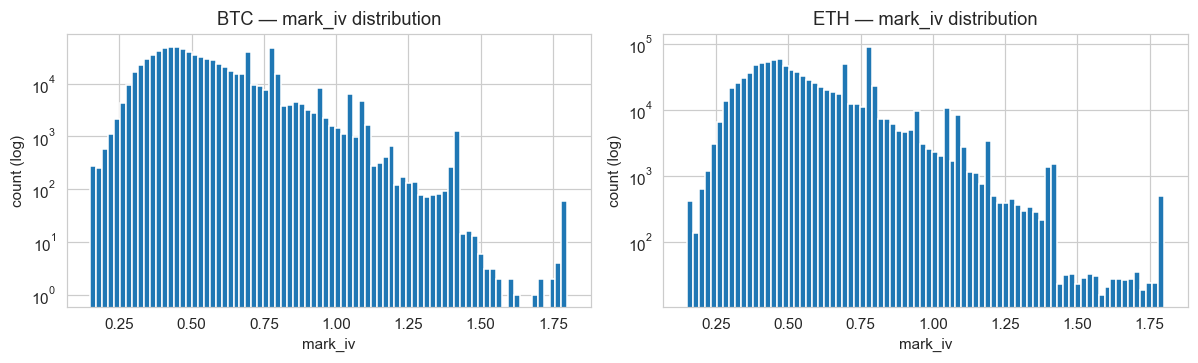

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for ax, df, name in zip(axes, [btc, eth], ["BTC", "ETH"]):
    ax.hist(df.mark_iv[df.mark_iv > 0], bins=80, log=True)
    ax.set_xlabel("mark_iv"); ax.set_ylabel("count (log)"); ax.set_title(f"{name} — mark_iv distribution")
plt.tight_layout()

## Days-to-expiry distribution\n\nWhat tenors do we actually have?

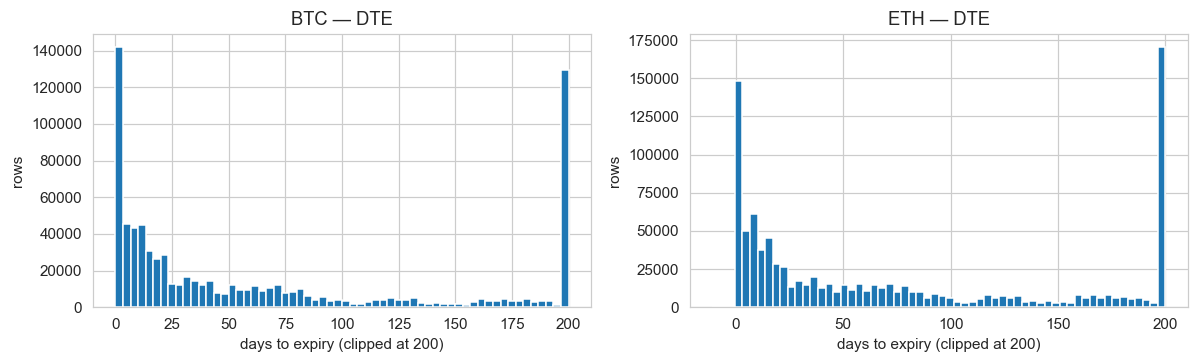

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for ax, df, name in zip(axes, [btc, eth], ["BTC", "ETH"]):
    ax.hist(df.dte.clip(upper=200), bins=60)
    ax.set_xlabel("days to expiry (clipped at 200)"); ax.set_ylabel("rows"); ax.set_title(f"{name} — DTE")
plt.tight_layout()

## Moneyness distribution\n\nProxy underlying via per-snapshot median strike of the highest-OI contract group.

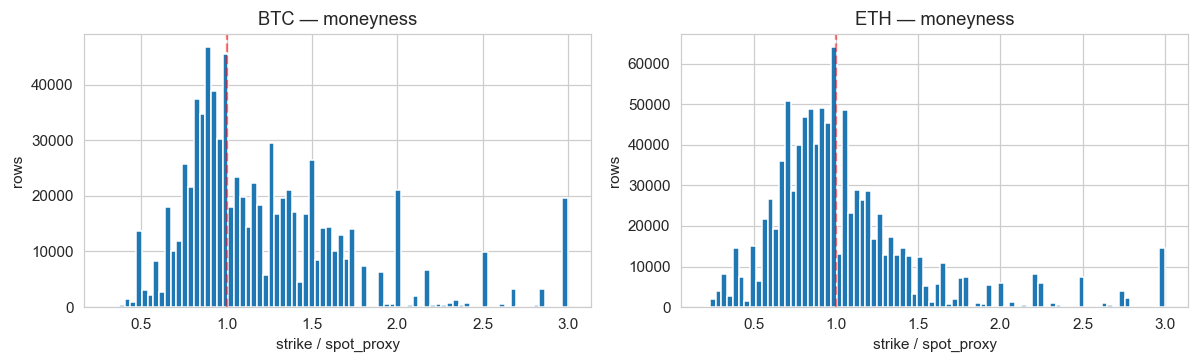

In [6]:
def add_moneyness(df: pd.DataFrame) -> pd.DataFrame:
    # Approximate underlying as the strike of the most-traded contract per snapshot
    # (good enough for moneyness diagnostics; we'll back out forwards properly later).
    proxy = (df[df.mark_iv > 0]
             .sort_values("openinterest_contracts", ascending=False)
             .drop_duplicates("ts")[["ts", "strike_parsed"]]
             .rename(columns={"strike_parsed": "spot_proxy"}))
    out = df.merge(proxy, on="ts", how="left")
    out["moneyness"] = out["strike_parsed"] / out["spot_proxy"]
    return out

btc_m = add_moneyness(btc)
eth_m = add_moneyness(eth)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for ax, df, name in zip(axes, [btc_m, eth_m], ["BTC", "ETH"]):
    ax.hist(df.moneyness.clip(0.2, 3.0), bins=80)
    ax.set_xlabel("strike / spot_proxy"); ax.set_ylabel("rows"); ax.set_title(f"{name} — moneyness")
    ax.axvline(1.0, color="r", ls="--", alpha=0.5)
plt.tight_layout()

## Sample smile — one snapshot, one expiry

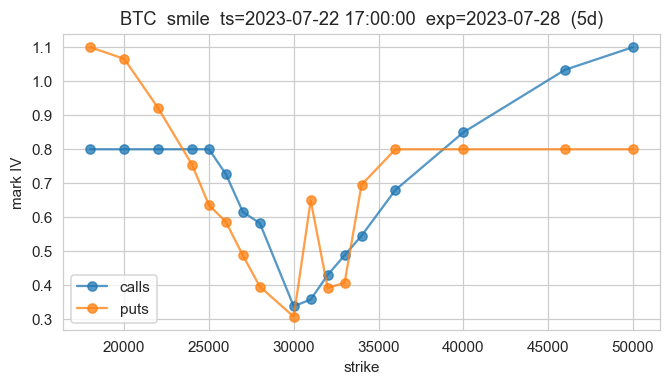

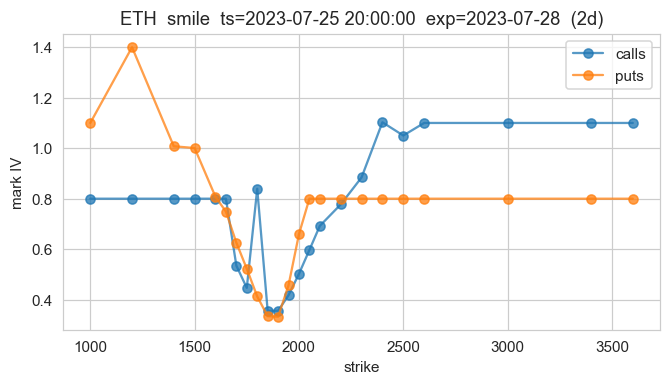

In [7]:
def smile(df: pd.DataFrame, name: str, snap_ts=None, expiry=None):
    if snap_ts is None:
        snap_ts = df.ts.iloc[len(df) // 2]
    sub_full = df[df.ts == snap_ts]
    if expiry is None:
        expiry = sub_full.expiry.value_counts().idxmax()
    sub = sub_full[(sub_full.expiry == expiry) & (sub_full.mark_iv > 0)].sort_values("strike_parsed")
    plt.figure(figsize=(7, 3.5))
    for opt_type, label in [("C", "calls"), ("P", "puts")]:
        s = sub[sub.type == opt_type]
        if len(s):
            plt.plot(s.strike_parsed, s.mark_iv, "o-", label=label, alpha=0.75)
    plt.xlabel("strike"); plt.ylabel("mark IV"); plt.legend()
    plt.title(f"{name}  smile  ts={snap_ts}  exp={expiry.date()}  ({(expiry - snap_ts).days}d)")

smile(btc, "BTC")
smile(eth, "ETH")

## Term structure — ATM IV by tenor

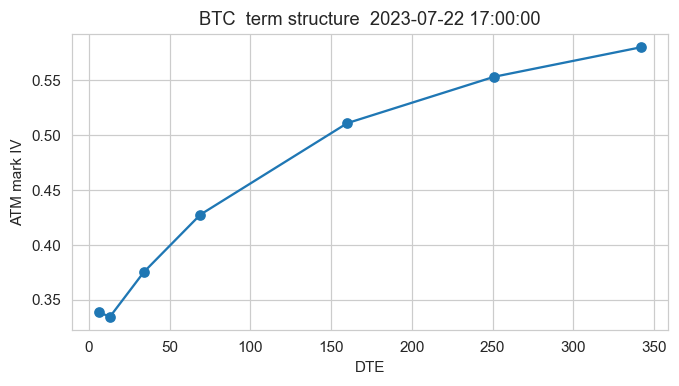

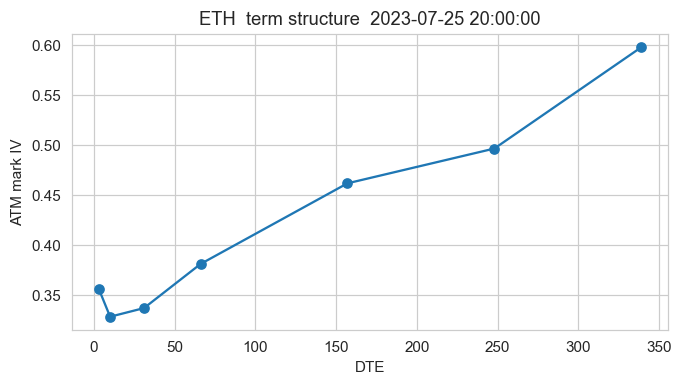

In [8]:
def term_struct(df: pd.DataFrame, name: str, snap_ts=None):
    if snap_ts is None:
        snap_ts = df.ts.iloc[len(df) // 2]
    sub = df[(df.ts == snap_ts) & (df.mark_iv > 0) & (df.type == "C")].copy()
    sub["atm_score"] = (sub.delta - 0.5).abs()
    atm = sub.loc[sub.groupby("expiry")["atm_score"].idxmin()].sort_values("dte")
    plt.figure(figsize=(7, 3.5))
    plt.plot(atm.dte, atm.mark_iv, "o-")
    plt.xlabel("DTE"); plt.ylabel("ATM mark IV"); plt.title(f"{name}  term structure  {snap_ts}")

term_struct(btc, "BTC")
term_struct(eth, "ETH")

## Vol level over time — 30d ATM IV

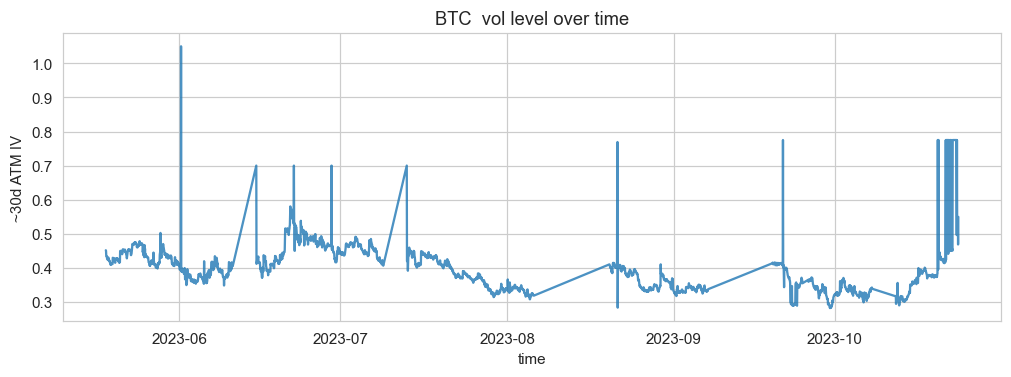

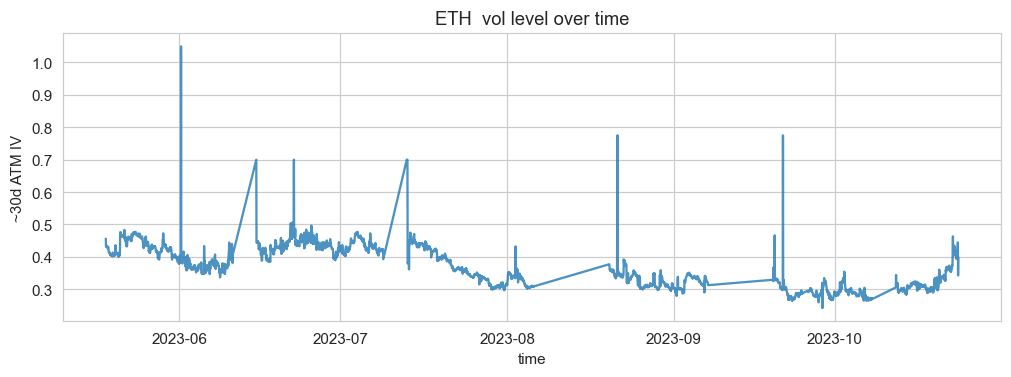

In [9]:
def vol_level(df: pd.DataFrame, name: str):
    calls = df[(df.type == "C") & (df.mark_iv > 0) & (df.dte.between(20, 40))].copy()
    calls["atm_score"] = (calls.delta - 0.5).abs()
    atm = calls.loc[calls.groupby("ts")["atm_score"].idxmin()].sort_values("ts")
    plt.figure(figsize=(11, 3.4))
    plt.plot(atm.ts, atm.mark_iv, alpha=0.8)
    plt.xlabel("time"); plt.ylabel("~30d ATM IV"); plt.title(f"{name}  vol level over time")

vol_level(btc, "BTC")
vol_level(eth, "ETH")

## 3D surface — one snapshot, calls only

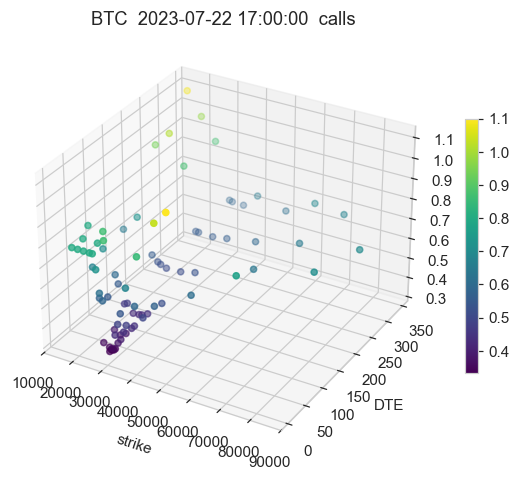

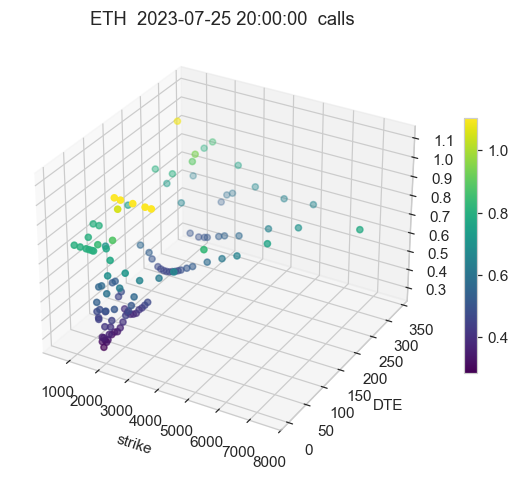

In [10]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

def surface_3d(df: pd.DataFrame, name: str, snap_ts=None):
    if snap_ts is None:
        snap_ts = df.ts.iloc[len(df) // 2]
    sub = df[(df.ts == snap_ts) & (df.mark_iv > 0) & (df.type == "C")]
    fig = plt.figure(figsize=(7, 5))
    ax = fig.add_subplot(111, projection="3d")
    p = ax.scatter(sub.strike_parsed, sub.dte, sub.mark_iv, c=sub.mark_iv, cmap="viridis", s=16)
    ax.set_xlabel("strike"); ax.set_ylabel("DTE"); ax.set_zlabel("mark IV")
    ax.set_title(f"{name}  {snap_ts}  calls")
    fig.colorbar(p, ax=ax, shrink=0.6)

surface_3d(btc, "BTC")
surface_3d(eth, "ETH")

## Quick arbitrage sanity — call prices should be monotone decreasing in strike per expiry

In [11]:
def arb_check(df: pd.DataFrame, name: str, snap_ts=None) -> None:
    if snap_ts is None:
        snap_ts = df.ts.iloc[len(df) // 2]
    sub = df[(df.ts == snap_ts) & (df.type == "C") & (df.mark_price > 0)]
    viol = 0; total = 0
    for _, g in sub.groupby("expiry"):
        prices = g.sort_values("strike_parsed").mark_price.values
        if len(prices) > 1:
            viol += int((np.diff(prices) > 0).sum())
            total += len(prices) - 1
    pct = 100 * viol / max(1, total)
    print(f"{name}  call monotonicity violations at {snap_ts}: {viol}/{total} ({pct:.1f}%)")

arb_check(btc, "BTC")
arb_check(eth, "ETH")

BTC  call monotonicity violations at 2023-07-22 17:00:00: 1/78 (1.3%)
ETH  call monotonicity violations at 2023-07-25 20:00:00: 3/110 (2.7%)
